# Algorithm 2: Decision Tree Classification

**CS 483 — Soccer Predictors**

This notebook contains the final code for Algorithm 2. The goal is to predict the match outcome:

- `1` = Home win
- `0` = Draw
- `-1` = Away win


## 1. Import libraries

We use pandas for loading and merging the data, scikit-learn for the Decision Tree model, and matplotlib/seaborn for graphs.


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree 
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


## 2. File setup

This notebook uses these files 

- `train-2.csv`
- `test-2.csv`
- `new_match_level_features.csv`

The notebook only needs these three files to reproduce the final Decision Tree result. The raw files (`events.csv`, `ginf.csv`) were used earlier to create `new_match_level_features.csv`.


In [37]:

DATA_DIR = "."
train_path = os.path.join(DATA_DIR, "train-2.csv")
test_path = os.path.join(DATA_DIR, "test-2.csv")
new_features_path = os.path.join(DATA_DIR, "new_match_level_features.csv")

required_files = [train_path, test_path, new_features_path]
for file in required_files:
    if not os.path.exists(file):
        raise FileNotFoundError(f"Missing file: {file}")

print("All required files were found.")


All required files were found.


## 3. Load the data

The training and testing data are already split by time.

In [39]:
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)
new_features = pd.read_csv(new_features_path)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("New features shape:", new_features.shape)

train_df.head()


Train shape: (6231, 31)
Test shape: (2748, 31)
New features shape: (9074, 25)


,date,league,season,country,home_team,away_team,match_result,home__is_shot_on_target_sum_avg,home__Shooting accuracy_avg,home__is_goal_sum_avg,...,away__CORNER_sum_avg,away__fast_break_sum_avg,goal_diff_avg,shot_on_target_diff_avg,shooting_accuracy_diff_avg,inside_box_diff_avg,cross_diff_avg,pass_assist_diff_avg,corner_diff_avg,fast_break_diff_avg
0,2011-08-13,D1,2012,germany,TSG Hoffenheim,Borussia Dortmund,1.0,5.0,0.625000,1.0,...,1.0,1.0,-2.0,0.0,0.208333,-6.0,1.0,-1.0,-1.0,-1.0
1,2011-08-13,F1,2012,france,St Etienne,AS Nancy Lorraine,1.0,2.0,0.250000,2.0,...,0.0,1.0,1.0,1.0,0.050000,3.0,1.0,2.0,1.0,-1.0
2,2011-08-13,D1,2012,germany,Nurnberg,Hannover 96,-1.0,7.0,0.636364,1.0,...,0.0,0.0,-1.0,3.0,-0.163636,2.0,1.0,3.0,1.0,0.0
3,2011-08-13,D1,2012,germany,Borussia Monchengladbach,VfB Stuttgart,0.0,3.0,0.750000,1.0,...,2.0,2.0,-2.0,-3.0,0.204545,-7.0,-3.0,0.0,-2.0,-2.0
4,2011-08-13,F1,2012,france,Valenciennes,Brest,0.0,6.0,0.666667,0.0,...,1.0,0.0,-2.0,-1.0,0.298246,-8.0,0.0,-8.0,0.0,0.0


## 4. Merge the additional event-based features

The new features include event-based information such as fouls, yellow cards, offsides, free kicks won, red cards, and total event activity. These were created from the raw event data and converted into historical rolling averages.


In [40]:
merge_cols = ["date", "league", "season", "country", "home_team", "away_team"]
for col in merge_cols:
    if col not in train_df.columns:
        raise KeyError(f"Column missing from train data: {col}")
    if col not in test_df.columns:
        raise KeyError(f"Column missing from test data: {col}")
    if col not in new_features.columns:
        raise KeyError(f"Column missing from new feature data: {col}")

train_df = train_df.merge(new_features, on=merge_cols, how="left")
test_df = test_df.merge(new_features, on=merge_cols, how="left")

# Since some early games have no past history, we fill those missing rolling values with 0.
train_df = train_df.fillna(0)
test_df = test_df.fillna(0)

print("Train shape after merge:", train_df.shape)
print("Test shape after merge:", test_df.shape)


Train shape after merge: (6231, 50)
Test shape after merge: (2748, 50)


## 5. Create one extra ratio feature

This feature compares the home team's historical scoring average to the away team's historical scoring average. It gives the tree another way to compare team strength.


In [41]:
train_df["goal_ratio"] = train_df["home__is_goal_sum_avg"] / (train_df["away__is_goal_sum_avg"] + 1)
test_df["goal_ratio"] = test_df["home__is_goal_sum_avg"] / (test_df["away__is_goal_sum_avg"] + 1)


## 6. Select features and target

We manually selected meaningful numerical features. The Decision Tree does not choose the original columns by itself it learns how to split the data using the features we give it.


In [43]:
selected_features = [
    "home__is_goal_sum_avg",
    "away__is_goal_sum_avg",
    "goal_diff_avg",
    "goal_ratio",

    "home__is_shot_on_target_sum_avg",
    "away__is_shot_on_target_sum_avg",
    "shot_on_target_diff_avg",

    "home__Shooting accuracy_avg",
    "away__Shooting accuracy_avg",
    "shooting_accuracy_diff_avg",

    "home__is_inside_box_sum_avg",
    "away__is_inside_box_sum_avg",
    "inside_box_diff_avg",

    "home__fouls_avg",
    "away__fouls_avg",
    "fouls_diff_avg",

    "home__yellow_cards_avg",
    "away__yellow_cards_avg",
    "yellow_cards_diff_avg",

    "home__offsides_avg",
    "away__offsides_avg",
    "offsides_diff_avg",

    "home__free_kicks_won_avg",
    "away__free_kicks_won_avg",
    "free_kicks_won_diff_avg",

    "home__total_events_avg",
    "away__total_events_avg",
    "total_events_diff_avg",

    "home__red_cards_avg",
    "away__red_cards_avg",
    "red_cards_diff_avg"
]

missing_cols = [col for col in selected_features if col not in train_df.columns]
if missing_cols:
    raise KeyError(f"Missing feature columns: {missing_cols}")

X_train = train_df[selected_features]
X_test = test_df[selected_features]

y_train = train_df["match_result"]
y_test = test_df["match_result"]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Class counts in test set:")
print(y_test.value_counts().sort_index())


X_train shape: (6231, 31)
X_test shape: (2748, 31)
Class counts in test set:
match_result
-1.0     781
 0.0     697
 1.0    1270
Name: count, dtype: int64


## 7. Train the Decision Tree model

We used a Decision Tree because it learns if-else style rules from the data. The parameters below control the size of the tree and help reduce overfitting.

- `max_depth=5`: limits how deep the tree can grow
- `min_samples_leaf=30`: each final leaf must contain at least 30 samples
- `min_samples_split=60`: a node needs at least 60 samples before it can split
- `random_state=42`: keeps the result reproducible


In [44]:
model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=30,
    min_samples_split=60,
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)


## 8. Evaluate the model

We evaluate the model using accuracy, precision, recall, F1-score, and a confusion matrix. Accuracy alone is not enough because the model can perform better on common classes like home wins and worse on harder classes like draws.


In [45]:
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, zero_division=0)
cm = confusion_matrix(y_test, y_pred, labels=[-1, 0, 1])

print("Decision Tree Accuracy:", accuracy)
print("\nClassification Report:")
print(report)
print("Confusion Matrix:")
print(cm)


Decision Tree Accuracy: 0.49272197962154296

Classification Report:
              precision    recall  f1-score   support

        -1.0       0.45      0.32      0.37       781
         0.0       0.31      0.05      0.09       697
         1.0       0.51      0.84      0.64      1270

    accuracy                           0.49      2748
   macro avg       0.43      0.40      0.37      2748
weighted avg       0.45      0.49      0.42      2748

Confusion Matrix:
[[ 249   38  494]
 [ 144   38  515]
 [ 157   46 1067]]


## 9. Confusion matrix graph

This graph shows where the model predicts correctly and where it makes mistakes. In our result, the model predicts home wins better than draws.


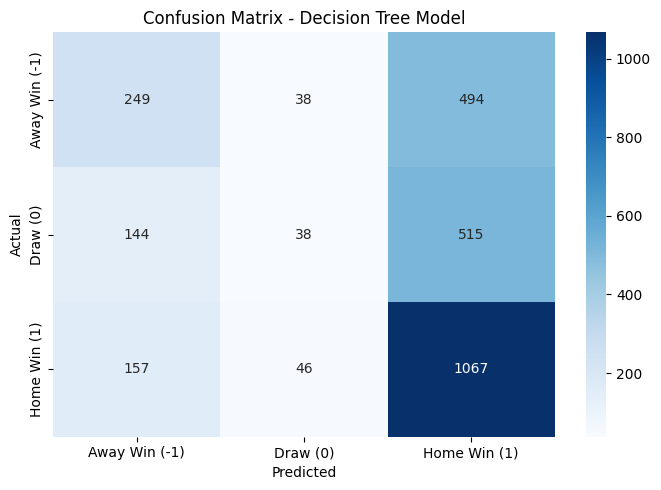

In [33]:
labels = ["Away Win (-1)", "Draw (0)", "Home Win (1)"]

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Decision Tree Model")
plt.tight_layout()
plt.savefig("confusion_matrix_decision_tree.png", dpi=200)
plt.show()


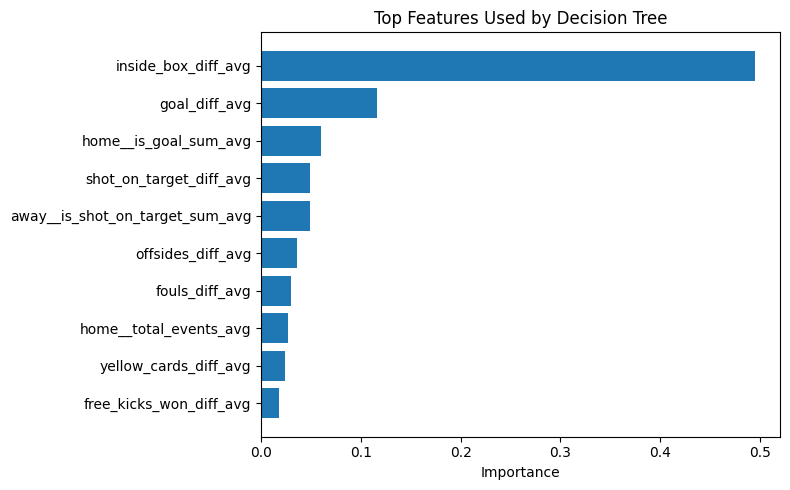

In [47]:
top_features = feature_importance.head(10).copy()

plt.figure(figsize=(8, 5))
plt.barh(top_features["feature"], top_features["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Top Features Used by Decision Tree")
plt.tight_layout()
plt.savefig("feature_importance_decision_tree.png", dpi=200)
plt.show()


## 12. Conclusion


The Decision Tree achieved about 49% accuracy. It performed best on home wins and struggled with draws. This matches what we saw during the project: draws are difficult to predict because they do not follow one clear pattern in the feature space. The feature importance graph shows that inside-box activity and goal-related features were important, which makes sense because they represent attacking strength and scoring chances.